# Binary Classification Pipeline: Churn Prediction

- Phase 1: EDA & Audit
Data Quality: Document dtypes, ranges, and null-handling strategy for 20 features.



---


- Phase 2: Preprocessing




Splitting: Utilize pre-defined churn-80 and churn-20 sets.




---



- Phase 3: Architecture Experiments
Variant A: Shallow Wide (1 layer, 128 units, ReLU).

Variant B: Deep Narrow (4 layers, 32 units, ReLU).

Variant C: Activation Swap (Test tanh and LeakyReLU).

Logging: Provide training/validation loss curves and parameter counts for all.


---


- Phase 4: Optimization & Stability
Regularization: Implement Dropout and Batch Normalization.

Callbacks: Integrate Early Stopping and Learning Rate Reduction.

A/B Tests: Compare Weight Initialization and Optimizers (Adam, SGD, RMSprop).

---

- Phase 5: Imbalance Management
Baselines: Compare "Always No-Churn" accuracy against model performance.

Resampling: Implement Class Weights and SMOTE.

Thresholds: Plot Precision-Recall curve and justify an optimal decision threshold.

---

- Phase 6: Evaluation
Full Report: Per-class F1, ROC-AUC, and Confusion Matrix on the test set.

Calibration: Provide an ROC Curve overlay and a Reliability Diagram.


# Phase 1

In [6]:
# !pip install scikit-learn --upgrade

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import precision_recall_curve,classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

In [8]:
df = pd.read_csv('/content/churn-bigml-80.csv')
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [10]:
# Document dtypes
print(df.dtypes)

State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [11]:
# Summary stats
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [12]:
# ceck nun
df.isna().sum().sum()

np.int64(0)

> NO nun -_-

# Phase 2

In [13]:
# Predefined splits
train_df = pd.read_csv("/content/churn-bigml-80.csv")
test_df = pd.read_csv("/content/churn-bigml-20.csv")

In [14]:
train_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [15]:
print(f'nan in train = {train_df.isna().sum().sum()}')
print(f'nan in test = {test_df.isna().sum().sum()}')

nan in train = 0
nan in test = 0


In [16]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]
X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [17]:
num_features = X_train.select_dtypes(include='number').columns
cat_features = X_train.select_dtypes(include='object').columns

In [18]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# Phase 3

In [19]:
def build_model(variant="A", activation="relu"):
    if variant == "A":  # Shallow Wide
        model = models.Sequential([
            layers.Dense(128, activation=activation),
            layers.Dense(1, activation="sigmoid")
        ])
    elif variant == "B":  # Deep Narrow
        model = models.Sequential([
            layers.Dense(32, activation=activation),
            layers.Dense(32, activation=activation),
            layers.Dense(32, activation=activation),
            layers.Dense(32, activation=activation),
            layers.Dense(1, activation="sigmoid")
        ])
    elif variant == "C":  # Activation Swap
        model = models.Sequential([
            layers.Dense(64, activation="leaky_relu"),
            layers.Dense(1, activation="sigmoid")
        ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [20]:
# Example training
modelA = build_model("A", "relu")
historyA = modelA.fit(preprocessor.fit_transform(X_train), y_train,
                      validation_split=0.2, epochs=50, batch_size=32)

modelA.summary()

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8180 - loss: 0.4607 - val_accuracy: 0.8258 - val_loss: 0.4116
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8644 - loss: 0.3341 - val_accuracy: 0.8371 - val_loss: 0.3682
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8851 - loss: 0.2992 - val_accuracy: 0.8502 - val_loss: 0.3399
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8940 - loss: 0.2719 - val_accuracy: 0.8689 - val_loss: 0.3158
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9095 - loss: 0.2499 - val_accuracy: 0.8652 - val_loss: 0.3041
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9137 - loss: 0.2332 - val_accuracy: 0.8839 - val_loss: 0.2820
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9221 - loss: 0.2197 - val_accuracy: 0.8801 - val_loss: 0.2775
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9250 - loss: 0.2098 - val_accuracy: 0.8858 - val_loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,037 (109.52 KB)

 Trainable params: 9,345 (36.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,692 (73.02 KB)

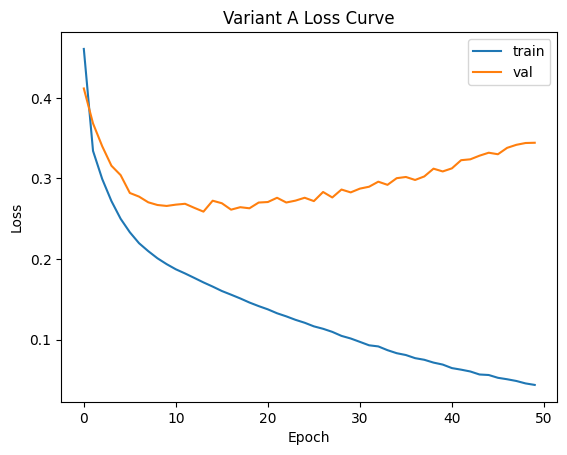

In [21]:
def plot_history(history, title):
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(historyA, "Variant A Loss Curve")

Model B Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,517 (64.52 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,012 (43.02 KB)

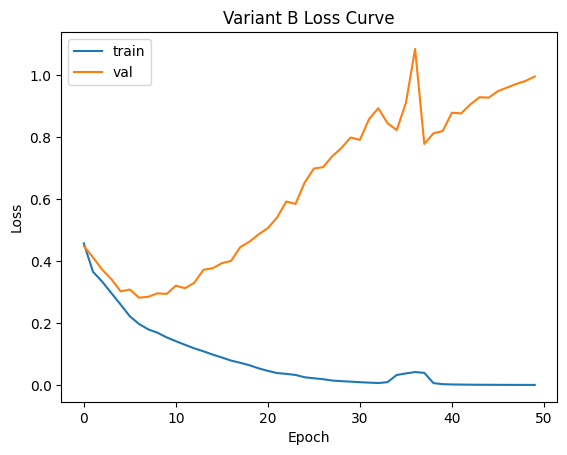

In [22]:
# Training for Variant B (Deep Narrow)
modelB = build_model("B", "relu")
historyB = modelB.fit(preprocessor.fit_transform(X_train), y_train,
                      validation_split=0.2, epochs=50, batch_size=32,
                      verbose=0) # to suppress epoch output

print("Model B Summary:")
modelB.summary()
plot_history(historyB, "Variant B Loss Curve")

Model C Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,021 (54.77 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,348 (36.52 KB)

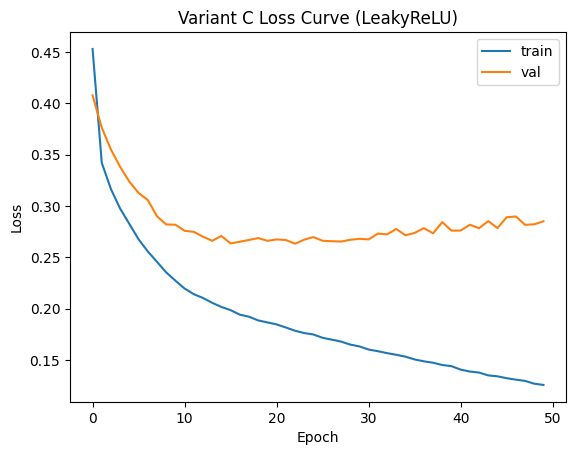

In [23]:
modelC = build_model("C", "leaky_relu")
historyC = modelC.fit(preprocessor.fit_transform(X_train), y_train,
                      validation_split=0.2, epochs=50, batch_size=32,
                      verbose=0)

print("Model C Summary:")
modelC.summary()
plot_history(historyC, "Variant C Loss Curve (LeakyReLU)")

# Phase 4

In [24]:
def build_regularized_model(optimizer="adam", init="he_normal"):
    model = models.Sequential([
        layers.Dense(64, activation="relu", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

model_reg = build_regularized_model("adam", "he_normal")
history_reg = model_reg.fit(preprocessor.fit_transform(X_train), y_train,
                            validation_split=0.2, epochs=100, batch_size=32,
                            callbacks=callbacks)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5572 - loss: 0.8646 - val_accuracy: 0.7247 - val_loss: 0.6143 - learning_rate: 0.0010
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6520 - loss: 0.6671 - val_accuracy: 0.8165 - val_loss: 0.5323 - learning_rate: 0.0010
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7420 - loss: 0.5506 - val_accuracy: 0.8464 - val_loss: 0.4634 - learning_rate: 0.0010
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7814 - loss: 0.4840 - val_accuracy: 0.8558 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8138 - loss: 0.4377 - val_accuracy: 0.8539 - val_loss: 0.3810 - learning_rate: 0.0010
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8349 - loss: 0.4009 - val_accuracy: 0.8577 - val_loss: 0.3571 - learning_rate: 0.0010
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8499 - loss: 0.3879 -

In [26]:
# Define candidate initializers and optimizers
initializers = ["he_normal", "glorot_uniform"]
optimizers = {
    "adam": tf.keras.optimizers.Adam(),
    "sgd": tf.keras.optimizers.SGD(),
    "rmsprop": tf.keras.optimizers.RMSprop()
}

def build_test_model(init="he_normal", optimizer_obj=None):
    model = models.Sequential([
        layers.Dense(64, activation="relu", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    if optimizer_obj is None:
        optimizer_obj = optimizers["adam"]

    model.compile(optimizer=optimizer_obj,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

In [27]:
results = {}

for init in initializers:
    for opt_name in optimizers.keys(): #avoid conflict
        print(f"\nTraining with init={init}, optimizer={opt_name}")
        if opt_name == "adam":
            current_optimizer = tf.keras.optimizers.Adam()
        elif opt_name == "sgd":
            current_optimizer = tf.keras.optimizers.SGD()
        elif opt_name == "rmsprop":
            current_optimizer = tf.keras.optimizers.RMSprop()

        model = build_test_model(init, optimizer_obj=current_optimizer)
        history = model.fit(preprocessor.fit_transform(X_train), y_train,
                            validation_split=0.2,
                            epochs=50,
                            batch_size=32,
                            verbose=0)
        # Evaluate
        val_acc = max(history.history['val_accuracy'])
        results[(init, opt_name)] = val_acc
        print(f"Best Val Accuracy: {val_acc:.4f}")


Training with init=he_normal, optimizer=adam
Best Val Accuracy: 0.9120

Training with init=he_normal, optimizer=sgd
Best Val Accuracy: 0.8464

Training with init=he_normal, optimizer=rmsprop
Best Val Accuracy: 0.9007

Training with init=glorot_uniform, optimizer=adam
Best Val Accuracy: 0.9195

Training with init=glorot_uniform, optimizer=sgd
Best Val Accuracy: 0.8801

Training with init=glorot_uniform, optimizer=rmsprop
Best Val Accuracy: 0.9082


In [28]:
df_results = pd.DataFrame([
    {"Initializer": init, "Optimizer": opt, "Best Val Acc": acc}
    for (init, opt), acc in results.items()
])

print(df_results)

      Initializer Optimizer  Best Val Acc
0       he_normal      adam      0.911985
1       he_normal       sgd      0.846442
2       he_normal   rmsprop      0.900749
3  glorot_uniform      adam      0.919476
4  glorot_uniform       sgd      0.880150
5  glorot_uniform   rmsprop      0.908240


# Phase 5

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
def justify_threshold(y_true, y_pred_proba, precision, recall, thresholds):
    # Calc F1-score for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores) # Handle potential NaN values where precision + recall = 0

    # Find the threshold that maximizes the F1-score
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"Optimal Threshold (max F1-score): {optimal_threshold:.4f}")

    # Plot optimal threshold
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label='Precision-Recall Curve')
    plt.scatter(recall[optimal_idx], precision[optimal_idx], marker='o', color='red', label=f'Optimal Threshold ({optimal_threshold:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Optimal Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Evaluate with the optimal threshold
    y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)
    print(f"\nClassification Report at Optimal Threshold ({optimal_threshold:.4f}):")
    print(classification_report(y_true, y_pred_optimal))

Always No-Churn accuracy: 0.8575712143928036
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5019 - loss: 1.6778 - val_accuracy: 0.5487 - val_loss: 0.6767
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5389 - loss: 1.4370 - val_accuracy: 0.6292 - val_loss: 0.6405
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5882 - loss: 1.2379 - val_accuracy: 0.6648 - val_loss: 0.5991
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6098 - loss: 1.1917 - val_accuracy: 0.7079 - val_loss: 0.5590
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6168 - loss: 1.1681 - val_accuracy: 0.7191 - val_loss: 0.5458
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6473 - loss: 1.0641 - val_accuracy: 0.7453 - val_loss: 0.5311
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6942 - loss: 0.9822 - val_accuracy: 0.7697 - val_loss: 0.5131
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6895 

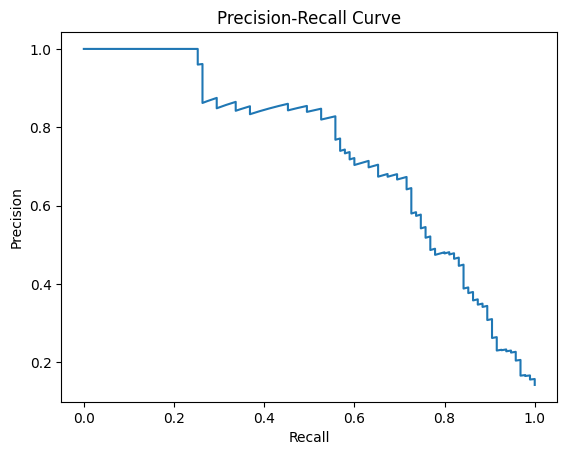

In [31]:
# Baseline accuracy
baseline_acc = (y_test == 0).mean()
print("Always No-Churn accuracy:", baseline_acc)

# Class weights
class_weight = {0:1, 1:sum(y_train==0)/sum(y_train==1)}

model_wt = build_regularized_model()
model_wt.fit(preprocessor.fit_transform(X_train), y_train,
             validation_split=0.2, epochs=50, batch_size=32,
             class_weight=class_weight)

# Precision-Recall curve
y_pred_proba = model_wt.predict(preprocessor.transform(X_test))
prec, rec, thresh = precision_recall_curve(y_test, y_pred_proba)

plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Original training set shape: (2666, 71), (2666,)
SMOTE training set shape: (4556, 71), (4556,)
Class distribution after SMOTE: Churn
False    2278
True     2278
Name: count, dtype: int64
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Optimal Threshold (max F1-score): 0.4607


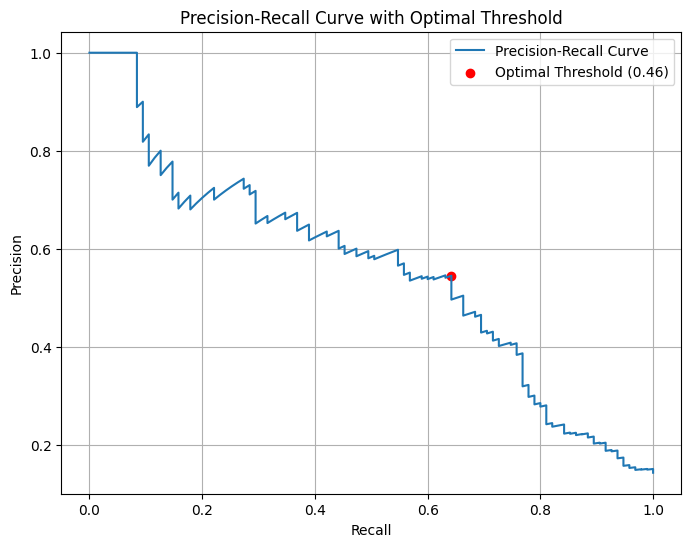


Classification Report at Optimal Threshold (0.4607):
              precision    recall  f1-score   support

       False       0.94      0.91      0.92       572
        True       0.54      0.63      0.58        95

    accuracy                           0.87       667
   macro avg       0.74      0.77      0.75       667
weighted avg       0.88      0.87      0.88       667



In [32]:
# Preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Original training set shape: {X_train_processed.shape}, {y_train.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {pd.Series(y_train_smote).value_counts()}")

model_smote = build_regularized_model()
history_smote = model_smote.fit(X_train_smote, y_train_smote,
                                validation_split=0.2, epochs=50, batch_size=32,
                                callbacks=callbacks,
                                verbose=0)

# Predict probabilities on the (un-SMOTEd) test set
y_pred_proba_smote = model_smote.predict(X_test_processed)

# Precision-Recall curve
precision_smote, recall_smote, thresholds_smote = precision_recall_curve(y_test, y_pred_proba_smote)

# Justify threshold
justify_threshold(y_test, y_pred_proba_smote, precision_smote, recall_smote, thresholds_smote)

# Phase 6

              precision    recall  f1-score   support

       False       0.96      0.86      0.90       572
        True       0.47      0.78      0.59        95

    accuracy                           0.85       667
   macro avg       0.72      0.82      0.75       667
weighted avg       0.89      0.85      0.86       667

ROC-AUC: 0.8969635627530363
Confusion Matrix:
 [[490  82]
 [ 21  74]]


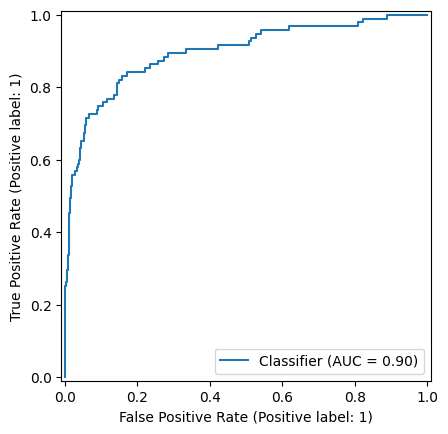

In [33]:
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.show()

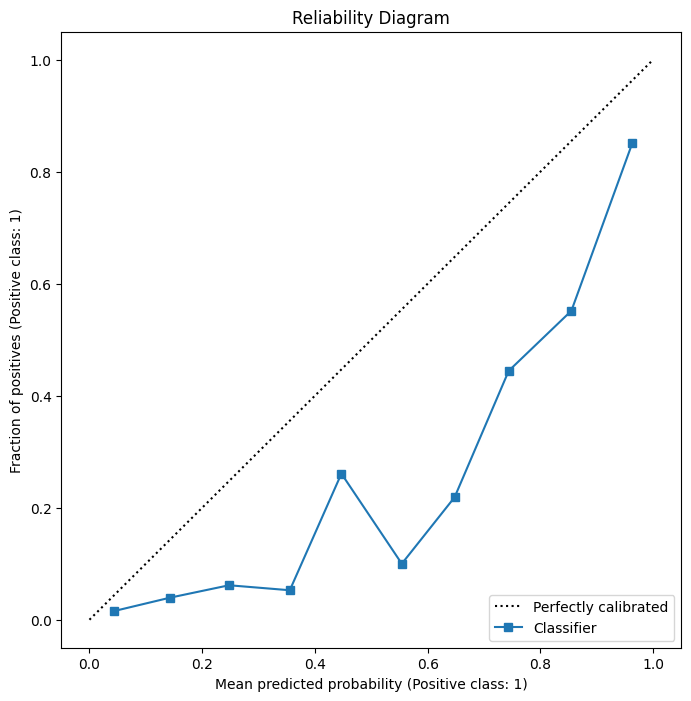

In [35]:
# Reliability Diagram
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(8, 8))
CalibrationDisplay.from_predictions(y_test, y_pred_proba, n_bins=10, ax=ax)
ax.set_title('Reliability Diagram')
plt.show()